# **Aula 6 - Mecanismos de Atenção e Transformers**

Na Aula 5, vimos que BERT e GPT geram embeddings **contextuais** -- o vetor de uma palavra muda dependendo da frase em que ela aparece. Mas não explicamos como isso acontece internamente.

O mecanismo por trás disso se chama **atenção** (*attention*), e é o núcleo da arquitetura **Transformer** (VASWANI et al., 2017) -- a arquitetura que sustenta BERT, GPT, e praticamente todo modelo de linguagem relevante hoje. Nesta aula, vamos construir um Transformer peça por peça, usando a mesma frase de exemplo (`"o cachorro latiu alto"`) do início ao fim, para entender exatamente o que cada peça faz.

## 1. Tokenização e Embeddings

O primeiro passo é o mesmo que já vimos na Aula 5: transformar cada palavra em um número (tokenização) e depois em um vetor denso (embedding). Aqui usaremos vetores bem pequenos (3 dimensões) só para conseguirmos inspecionar os números diretamente.

In [1]:
#Passo 1: Tokenização (simplificada)

# Frase de entrada
sentence = "o cachorro latiu alto"

# Tokenização simples: separação por espaços
tokens = sentence.split()
print("Tokens:", tokens)  # ['o', 'cachorro', 'latiu', 'alto']

# Criar vocabulário: conjunto único de palavras
vocab = list(set(tokens))
print("Vocabulário:", vocab)

# Mapear palavras para índices (word2idx) e o contrário (idx2word)
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

print("Mapeamento palavra → índice:", word2idx)
print("Mapeamento índice → palavra:", idx2word)

Tokens: ['o', 'cachorro', 'latiu', 'alto']
Vocabulário: ['alto', 'cachorro', 'o', 'latiu']
Mapeamento palavra → índice: {'alto': 0, 'cachorro': 1, 'o': 2, 'latiu': 3}
Mapeamento índice → palavra: {0: 'alto', 1: 'cachorro', 2: 'o', 3: 'latiu'}


In [2]:
# Passo 2: Embedding, que é onde cada token (já convertido em número no passo anterior) passa a ser representado por um vetor denso de números reais, chamado embedding.
import torch
import torch.nn as nn
torch.manual_seed(42)

# Tamanho do vocabulário e dimensão do embedding
vocab_size = len(vocab)
embedding_dim = 3  # número de dimensões do vetor de cada palavra

# Criar camada de embedding (inicializada aleatoriamente)
embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)

# Visualizar o vetor de embedding de cada token da frase
for token in tokens:
    idx = torch.tensor([word2idx[token]])  # índice da palavra
    emb = embedding_layer(idx)             # vetor embedding correspondente
    print(f'"{token}" → {emb.detach().numpy()[0]}')

"o" → [ 2.2082014  -0.63799703  0.46165723]
"cachorro" → [ 0.23033303 -1.1228564  -0.18632829]
"latiu" → [0.26735088 0.53490466 0.8093572 ]
"alto" → [0.33669037 0.1288094  0.23446237]


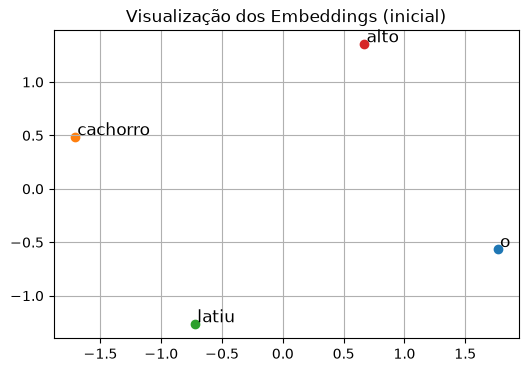

In [3]:
# Visualizar esses embeddings em 2D:

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Seus embeddings
embeddings = {
    "o": [-1.0048575, 0.9339107, -0.22706987],
    "cachorro": [1.936605, -1.1842352, -0.43182123],
    "latiu": [-0.06030979, -1.4818002, -0.33470765],
    "alto": [1.1746705, 1.1811255, 0.1018764]
}

labels = list(embeddings.keys())
X = np.array(list(embeddings.values()))

# Reduzir para 2D com PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot
plt.figure(figsize=(6, 4))
for i, label in enumerate(labels):
    x, y = X_pca[i]
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, label, fontsize=12)
plt.title("Visualização dos Embeddings (inicial)")
plt.grid(True)
plt.show()

## 2. Positional Encoding

O Transformer processa todos os tokens **em paralelo** (diferente da RNN/LSTM, que processam um de cada vez, em ordem). Isso é ótimo para velocidade, mas cria um problema: sem noção de ordem, `"o cachorro latiu alto"` e `"alto latiu cachorro o"` ficariam indistinguíveis.

A solução é somar, a cada embedding, um vetor que codifica a **posição** do token na sequência -- o *positional encoding*. Existem duas abordagens comuns: aprendida (mais um parâmetro treinável) ou fixa, usando senos e cossenos (a versão do artigo original de VASWANI et al., 2017).

In [4]:
torch.manual_seed(42)
# Passo 3: Positional Encoding
#  Como funciona? Existem duas abordagens comuns:
#	1.	Aprendida (como um embedding de posição)
#	2.	Fixa (usando funções seno/cosseno com base no artigo original)
# Vamos usar a versão aprendida — mais simples para fins didáticos.

# Dimensão dos embeddings (precisa ser igual à dos embeddings de palavra)
embedding_dim = 3
seq_len = len(tokens)  # 4 tokens: "o", "cachorro", "latiu", "alto"

# Criamos vetores de posição como parâmetros treináveis
# 1 vetor para cada posição (0, 1, 2, 3)
positional_encoding = nn.Parameter(torch.randn(1, seq_len, embedding_dim))

# Exibir os vetores de posição
print("Positional Encoding (aprendido):")
for i in range(seq_len):
    print(f"posição {i}: {positional_encoding[0, i].detach().numpy()}")

Positional Encoding (aprendido):
posição 0: [0.33669037 0.1288094  0.23446237]
posição 1: [ 0.23033303 -1.1228564  -0.18632829]
posição 2: [ 2.2082014  -0.63799703  0.46165723]
posição 3: [0.26735088 0.53490466 0.8093572 ]


In [5]:
# Positional Encoding – Versão do Artigo (seno/cosseno)

import numpy as np
import torch

def get_positional_encoding(seq_len, d_model):
    PE = np.zeros((seq_len, d_model))
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            angle = pos / np.power(10000, (2 * i) / d_model)
            PE[pos, i] = np.sin(angle)
            if i + 1 < d_model:
                PE[pos, i + 1] = np.cos(angle)
    return torch.tensor(PE, dtype=torch.float32)

# Exemplo com a frase: "o cachorro latiu alto"
seq_len = 4  # número de tokens
d_model = 3  # mesma dimensão dos embeddings

pos_enc = get_positional_encoding(seq_len, d_model)
print("Positional Encoding (seno/cosseno):")
for i in range(seq_len):
    print(f"posição {i}: {pos_enc[i].numpy()}")

Positional Encoding (seno/cosseno):
posição 0: [0. 1. 0.]
posição 1: [8.4147096e-01 5.4030228e-01 4.6415889e-06]
posição 2: [ 9.0929741e-01 -4.1614684e-01  9.2831779e-06]
posição 3: [ 1.4112000e-01 -9.8999250e-01  1.3924767e-05]


A soma do embedding com o positional encoding é a entrada real do Transformer -- o vetor resultante carrega tanto o significado da palavra quanto sua posição na frase.

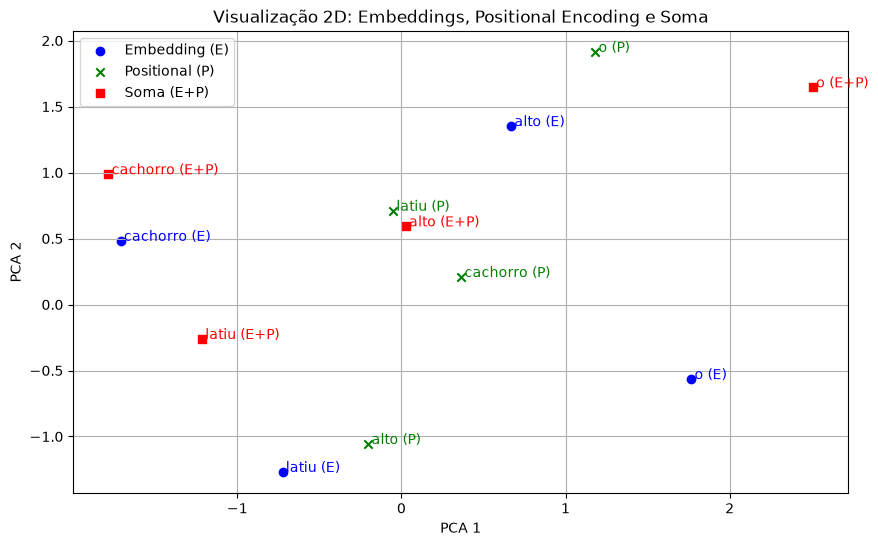

In [6]:
# Visualizar esses embeddings em 2D:

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Embeddings de exemplo
embeddings = {
    "o": [-1.0048575, 0.9339107, -0.22706987],
    "cachorro": [1.936605, -1.1842352, -0.43182123],
    "latiu": [-0.06030979, -1.4818002, -0.33470765],
    "alto": [1.1746705, 1.1811255, 0.1018764]
}

# Positional Encodings aprendidos
positional_encodings = {
    "o": [1.4040295, 2.2627833, -2.0864203],
    "cachorro": [0.41430452, 0.12562564, 0.83773607],
    "latiu": [1.0352697, -0.01277053, 1.5968297],
    "alto": [-0.21339168, -0.95826584, -0.1597742]
}

# Soma dos vetores
summed = {
    token: np.add(embeddings[token], positional_encodings[token])
    for token in embeddings
}

# PCA para reduzir para 2D
labels = list(embeddings.keys())
X_emb = np.array([embeddings[t] for t in labels])
X_pos = np.array([positional_encodings[t] for t in labels])
X_sum = np.array([summed[t] for t in labels])

pca = PCA(n_components=2)
X_emb_2d = pca.fit_transform(X_emb)
X_pos_2d = pca.transform(X_pos)
X_sum_2d = pca.transform(X_sum)

# Plot
plt.figure(figsize=(10, 6))
for i, label in enumerate(labels):
    plt.scatter(X_emb_2d[i, 0], X_emb_2d[i, 1], color='blue', marker='o')
    plt.text(X_emb_2d[i, 0] + 0.02, X_emb_2d[i, 1], f"{label} (E)", color='blue')
    plt.scatter(X_pos_2d[i, 0], X_pos_2d[i, 1], color='green', marker='x')
    plt.text(X_pos_2d[i, 0] + 0.02, X_pos_2d[i, 1], f"{label} (P)", color='green')
    plt.scatter(X_sum_2d[i, 0], X_sum_2d[i, 1], color='red', marker='s')
    plt.text(X_sum_2d[i, 0] + 0.02, X_sum_2d[i, 1], f"{label} (E+P)", color='red')

plt.title("Visualização 2D: Embeddings, Positional Encoding e Soma")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.legend(["Embedding (E)", "Positional (P)", "Soma (E+P)"])
plt.show()

## 3. Self-Attention: o coração do Transformer

Para cada token, o Transformer (VASWANI et al., 2017) pergunta: "quais outras palavras da frase são relevantes para entender esta aqui?". Ele faz isso projetando cada vetor em três papéis diferentes:

- **Query (Q)**: o que este token está "procurando".
- **Key (K)**: o que cada token "oferece" para ser encontrado.
- **Value (V)**: a informação que de fato será usada.

O peso de atenção entre dois tokens é o produto escalar entre a Query de um e a Key do outro (normalizado por softmax) -- quanto maior o produto, mais o primeiro token "presta atenção" no segundo. Vamos calcular isso manualmente para dois tokens da nossa frase, `"cachorro"` e `"latiu"`.

In [7]:
# Passo 4 - Self-Attention - Código completo — Self-Attention entre “cachorro” e “latiu” (com vetores reais):
import numpy as np

# Vetores somados (embedding + posição)
x_cachorro = np.array([1.936605, -1.1842352, -0.43182123]) + np.array([0.41430452, 0.12562564, 0.83773607])
x_latiu = np.array([-0.06030979, -1.4818002, -0.33470765]) + np.array([1.0352697, -0.01277053, 1.5968297])

# Matrizes de projeção (didáticas)
Wq = np.array([[0.1, 0.2, 0.3],
               [0.4, 0.5, 0.6],
               [0.7, 0.8, 0.9]])

Wk = np.array([[0.9, 0.8, 0.7],
               [0.6, 0.5, 0.4],
               [0.3, 0.2, 0.1]])

Wv = np.identity(3)  # facilita a visualização dos V

# Função softmax
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

# Q, K, V para os dois tokens
Q1 = x_cachorro @ Wq
Q2 = x_latiu @ Wq
K1 = x_cachorro @ Wk
K2 = x_latiu @ Wk
V1 = x_cachorro
V2 = x_latiu

# Scores de atenção (dot product entre Q e K)
dk = 3  # dimensão
scores_1 = np.array([Q1 @ K1.T, Q1 @ K2.T]) / np.sqrt(dk)
scores_2 = np.array([Q2 @ K1.T, Q2 @ K2.T]) / np.sqrt(dk)

# Pesos de atenção com softmax
weights_1 = softmax(scores_1)
weights_2 = softmax(scores_2)

# Resultado da atenção: soma ponderada dos V
attended_1 = weights_1[0] * V1 + weights_1[1] * V2
attended_2 = weights_2[0] * V1 + weights_2[1] * V2

# Mostrar resultado
print("Pesos de atenção para 'cachorro':", weights_1)
print("Vetor final para 'cachorro':", attended_1)
print("\nPesos de atenção para 'latiu':", weights_2)
print("Vetor final para 'latiu':", attended_2)

Pesos de atenção para 'cachorro': [0.62461052 0.37538948]
Vetor final para 'cachorro': [ 1.83439251 -1.2222648   0.72732602]

Pesos de atenção para 'latiu': [0.71113626 0.28886374]
Vetor final para 'latiu': [ 1.95344757 -1.18454293  0.65324205]


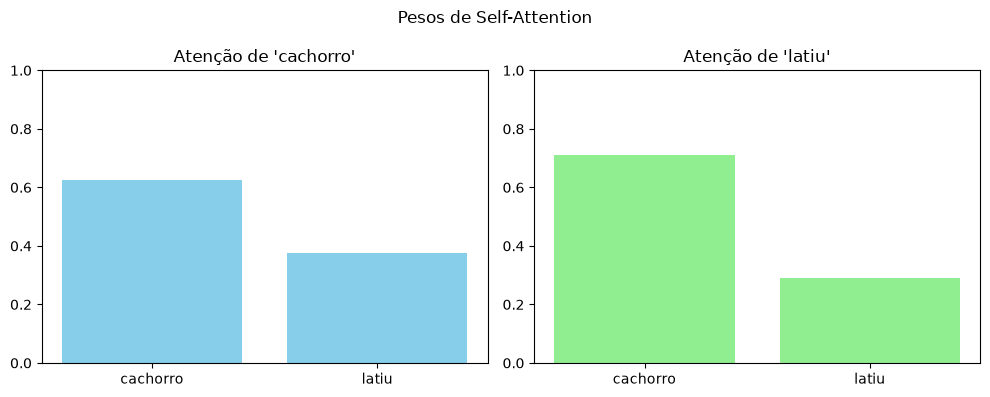

In [8]:
# Código: Visualização dos Pesos de Self-Attention

import matplotlib.pyplot as plt
import numpy as np

# Vetores de entrada (embedding + posição somados)
x_cachorro = np.array([1.936605, -1.1842352, -0.43182123]) + np.array([0.41430452, 0.12562564, 0.83773607])
x_latiu = np.array([-0.06030979, -1.4818002, -0.33470765]) + np.array([1.0352697, -0.01277053, 1.5968297])

# Matrizes de projeção
Wq = np.array([[0.1, 0.2, 0.3],
               [0.4, 0.5, 0.6],
               [0.7, 0.8, 0.9]])
Wk = np.array([[0.9, 0.8, 0.7],
               [0.6, 0.5, 0.4],
               [0.3, 0.2, 0.1]])
Wv = np.identity(3)

# Q, K, V
Q1 = x_cachorro @ Wq
Q2 = x_latiu @ Wq
K1 = x_cachorro @ Wk
K2 = x_latiu @ Wk

# Scores
dk = 3
scores_1 = np.array([Q1 @ K1.T, Q1 @ K2.T]) / np.sqrt(dk)
scores_2 = np.array([Q2 @ K1.T, Q2 @ K2.T]) / np.sqrt(dk)

# Softmax
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

weights_1 = softmax(scores_1)
weights_2 = softmax(scores_2)

# Plot dos pesos de atenção
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(["cachorro", "latiu"], weights_1, color="skyblue")
ax[0].set_title("Atenção de 'cachorro'")
ax[0].set_ylim(0, 1)

ax[1].bar(["cachorro", "latiu"], weights_2, color="lightgreen")
ax[1].set_title("Atenção de 'latiu'")
ax[1].set_ylim(0, 1)

plt.suptitle("Pesos de Self-Attention")
plt.tight_layout()
plt.show()

O gráfico mostra o quanto cada um dos dois tokens presta atenção em si mesmo e no outro -- essa é a mesma conta que, na prática, o Transformer faz entre **todos os pares** de tokens da frase, não só esses dois.

## 4. Multi-Head Attention

Uma única "cabeça" de atenção só consegue aprender um tipo de relação entre os tokens. O Transformer (VASWANI et al., 2017) roda **várias cabeças em paralelo**, cada uma com suas próprias matrizes Q, K, V -- uma pode aprender a focar em quem faz a ação, outra em como a ação foi feita, e assim por diante. No final, os resultados de todas as cabeças são concatenados e combinados numa única representação.

Vamos usar `nn.MultiheadAttention` do PyTorch (2 cabeças) na nossa frase inteira.

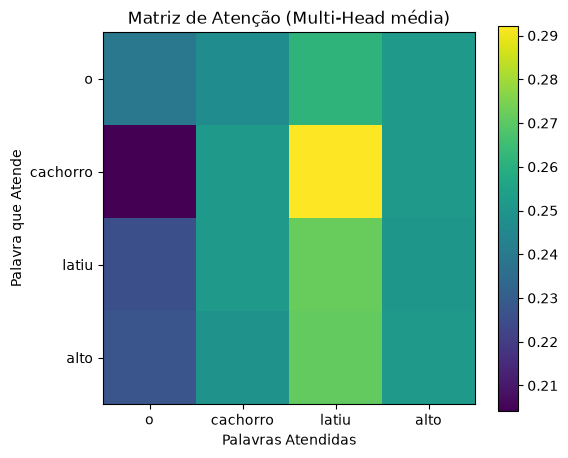

In [9]:
# Passo 5: Multi-Head Attention — uma das inovações mais poderosas do Transformer.
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(42)

# Tokens e vetores somados (embedding + posição)
tokens = ["o", "cachorro", "latiu", "alto"]
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4040295, 2.2627833, -2.0864203]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.41430452, 0.12562564, 0.83773607]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0352697, -0.01277053, 1.5968297]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.21339168, -0.95826584, -0.1597742])
}

# 1. Montar tensor de entrada (batch_size=1, seq_len=4, embed_dim=3)
x = torch.stack([summed[token] for token in tokens]).unsqueeze(0)  # [1, 4, 3]

# 2. Como embed_dim precisa ser divisível por num_heads, vamos projetar para 4 dimensões
proj = nn.Linear(3, 4)
x_proj = proj(x)  # [1, 4, 4]

# 3. Criar Multi-Head Attention (2 cabeças)
mha = nn.MultiheadAttention(embed_dim=4, num_heads=2, batch_first=True)
attn_output, attn_weights = mha(x_proj, x_proj, x_proj, need_weights=True)  # x como Q, K, V

# 4. Visualizar a matriz de atenção
weights = attn_weights[0].detach().numpy()  # [4, 4]
plt.figure(figsize=(6, 5))
plt.imshow(weights, cmap='viridis')
plt.xticks(np.arange(4), tokens)
plt.yticks(np.arange(4), tokens)
plt.title("Matriz de Atenção (Multi-Head média)")
plt.xlabel("Palavras Atendidas")
plt.ylabel("Palavra que Atende")
plt.colorbar()
plt.show()

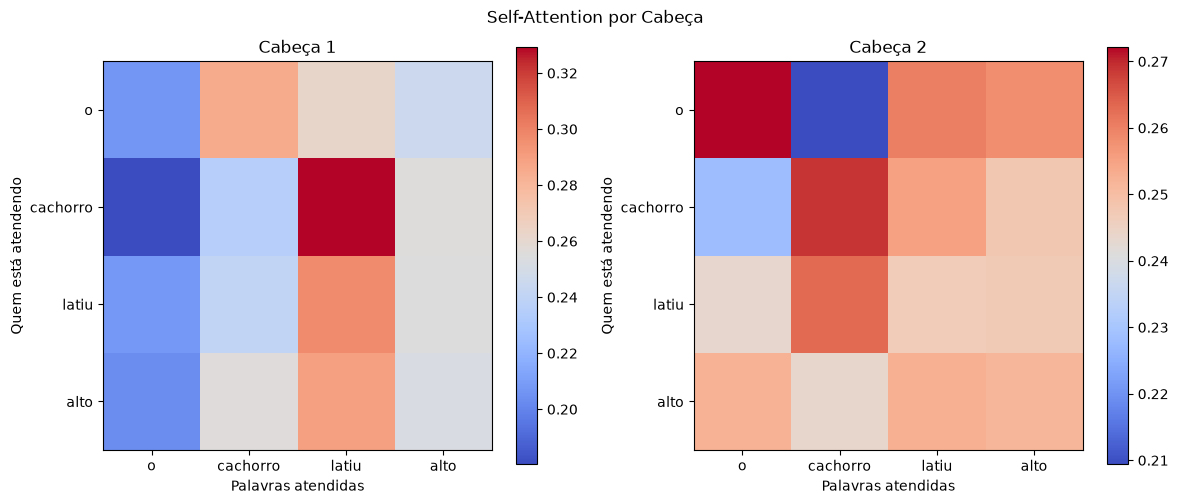

In [10]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
torch.manual_seed(42)

# Tokens
tokens = ["o", "cachorro", "latiu", "alto"]

# Vetores (embedding + posição)
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4040295, 2.2627833, -2.0864203]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.41430452, 0.12562564, 0.83773607]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0352697, -0.01277053, 1.5968297]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.21339168, -0.95826584, -0.1597742])
}

# Embedding final
x = torch.stack([summed[token] for token in tokens]).unsqueeze(0)  # [1, 4, 3]

# Projeção para embed_dim = 4 (para 2 cabeças)
proj = nn.Linear(3, 4)
x_proj = proj(x)

# Multi-Head Attention com average_attn_weights=False
mha = nn.MultiheadAttention(embed_dim=4, num_heads=2, batch_first=True)
attn_output, attn_weights = mha(x_proj, x_proj, x_proj, need_weights=True, average_attn_weights=False)

# attn_weights: [1, num_heads, seq_len, seq_len]
attn_weights = attn_weights[0].detach().numpy()  # shape: [2, 4, 4]

# Visualizar cada cabeça separadamente
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for head in range(2):
    ax = axes[head]
    im = ax.imshow(attn_weights[head], cmap='coolwarm')
    ax.set_title(f"Cabeça {head+1}")
    ax.set_xticks(np.arange(4))
    ax.set_yticks(np.arange(4))
    ax.set_xticklabels(tokens)
    ax.set_yticklabels(tokens)
    ax.set_xlabel("Palavras atendidas")
    ax.set_ylabel("Quem está atendendo")
    plt.colorbar(im, ax=ax)

plt.suptitle("Self-Attention por Cabeça")
plt.tight_layout()
plt.show()

Cada mapa de calor mostra, para uma cabeça, o peso de atenção de cada token (linha) sobre cada outro token (coluna) -- quanto mais forte a cor, maior o peso. Cada linha soma 1 (é uma distribuição de probabilidade sobre "onde olhar").

In [11]:
# 6 - Soma Ponderada dos Valores: Com os pesos de atenção, o modelo gera uma nova versão de cada vetor, agora contextualizada

import torch
import torch.nn as nn
import numpy as np
torch.manual_seed(42)

# Tokens
tokens = ["o", "cachorro", "latiu", "alto"]

# Vetores (embedding + posição)
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4040295, 2.2627833, -2.0864203]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.41430452, 0.12562564, 0.83773607]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0352697, -0.01277053, 1.5968297]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.21339168, -0.95826584, -0.1597742])
}

# Tensor de entrada (1 frase, 4 tokens, 3 dimensões)
x = torch.stack([summed[token] for token in tokens]).unsqueeze(0)  # [1, 4, 3]

# Projeção para 4 dimensões (divisível por 2 cabeças)
proj = nn.Linear(3, 4)
x_proj = proj(x)

# MultiheadAttention com 2 cabeças
mha = nn.MultiheadAttention(embed_dim=4, num_heads=2, batch_first=True)
attn_output, attn_weights = mha(x_proj, x_proj, x_proj, need_weights=True, average_attn_weights=False)

# Mostrar resultados
print("Atenção por cabeça (forma: [head, atendente, atendido]):")
print(attn_weights.shape)  # [1, heads, seq, seq]

for i, token in enumerate(tokens):
    print(f"\nToken '{token}':")
    for head in range(2):
        pesos = attn_weights[0, head, i].detach().numpy()
        print(f"  Cabeça {head+1} - pesos de atenção: {pesos.round(3)}")
    print(f"  Vetor contextualizado (saida): {attn_output[0, i].detach().numpy().round(3)}")

Atenção por cabeça (forma: [head, atendente, atendido]):
torch.Size([1, 2, 4, 4])

Token 'o':
  Cabeça 1 - pesos de atenção: [0.207 0.285 0.262 0.246]
  Cabeça 2 - pesos de atenção: [0.272 0.209 0.26  0.258]
  Vetor contextualizado (saida): [-0.21   0.09   0.414 -0.335]

Token 'cachorro':
  Cabeça 1 - pesos de atenção: [0.18  0.235 0.329 0.255]
  Cabeça 2 - pesos de atenção: [0.228 0.269 0.255 0.248]
  Vetor contextualizado (saida): [-0.19   0.088  0.413 -0.31 ]

Token 'latiu':
  Cabeça 1 - pesos de atenção: [0.208 0.241 0.297 0.255]
  Cabeça 2 - pesos de atenção: [0.243 0.263 0.247 0.247]
  Vetor contextualizado (saida): [-0.19   0.085  0.41  -0.324]

Token 'alto':
  Cabeça 1 - pesos de atenção: [0.203 0.255 0.289 0.252]
  Cabeça 2 - pesos de atenção: [0.252 0.244 0.253 0.252]
  Vetor contextualizado (saida): [-0.197  0.087  0.412 -0.325]


**Um ponto importante:** essas matrizes Q, K e V ainda não foram treinadas -- os pesos são aleatórios. Por isso, os pesos de atenção acima ficam próximos de uniformes (cada token dá um peso parecido para todos os outros), sem nenhum padrão linguístico claro ainda. É só **depois do treinamento** (ajustando os pesos via backpropagation, como vimos desde a Aula 1) que o modelo aprende a concentrar a atenção em tokens de fato relevantes -- por exemplo, o verbo prestando mais atenção no seu sujeito. O que vimos aqui é o **mecanismo**, não o resultado de um modelo treinado.

## 5. Feedforward, Resíduos e Normalização

Depois da atenção, cada token passa individualmente por uma pequena rede feedforward (a mesma ideia de camada densa + ReLU que já vimos desde a Aula 2). Em seguida, duas técnicas estabilizam o treinamento de redes tão profundas:

- **Conexão residual** (HE et al., 2016): soma-se a entrada original ao resultado da transformação (`saída = entrada + transformação(entrada)`), preservando a informação mesmo que a transformação "erre" no início do treino.
- **Layer Normalization** (BA; KIROS; HINTON, 2016): reescala cada vetor para ter média ≈ 0 e desvio-padrão ≈ 1, evitando que os valores explodam ou saturem à medida que passam por muitas camadas.

In [12]:
# Passo 7 – Feedforward Layer
import torch
import torch.nn as nn
import numpy as np
torch.manual_seed(42)

# Tokens e vetores (embedding + posição somados)
tokens = ["o", "cachorro", "latiu", "alto"]
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4040295, 2.2627833, -2.0864203]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.41430452, 0.12562564, 0.83773607]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0352697, -0.01277053, 1.5968297]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.21339168, -0.95826584, -0.1597742])
}

# Entrada: [1, 4, 3]
x = torch.stack([summed[t] for t in tokens]).unsqueeze(0)

# Projeção para 4 dimensões (Multihead requer divisibilidade por número de heads)
proj = nn.Linear(3, 4)
x_proj = proj(x)

# Multi-Head Attention (2 cabeças)
mha = nn.MultiheadAttention(embed_dim=4, num_heads=2, batch_first=True)
attn_output, _ = mha(x_proj, x_proj, x_proj)

# Feedforward Layer (4 -> 16 -> 4)
feedforward = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 4)
)

# Aplicar FFN
attn_output_ffn = feedforward(attn_output)

# Mostrar resultados
print("Comparação antes e depois da FFN:\n")
for i, token in enumerate(tokens):
    antes = attn_output[0, i].detach().numpy()
    depois = attn_output_ffn[0, i].detach().numpy()
    print(f"{token.upper()}")
    print("Antes da FFN:", np.round(antes, 3))
    print("Depois da FFN:", np.round(depois, 3))
    print()

Comparação antes e depois da FFN:

O
Antes da FFN: [-0.21   0.09   0.414 -0.335]
Depois da FFN: [-0.253 -0.009 -0.145  0.049]

CACHORRO
Antes da FFN: [-0.19   0.088  0.413 -0.31 ]
Depois da FFN: [-0.251 -0.016 -0.14   0.05 ]

LATIU
Antes da FFN: [-0.19   0.085  0.41  -0.324]
Depois da FFN: [-0.25  -0.014 -0.142  0.049]

ALTO
Antes da FFN: [-0.197  0.087  0.412 -0.325]
Depois da FFN: [-0.251 -0.013 -0.143  0.049]



In [13]:
# Passo 8 – Residual + Normalização
import torch
import torch.nn as nn
import numpy as np

# Supondo que já temos:
# - attn_output: saída do multi-head attention [1, 4, 4]
# - attn_output_ffn: saída da FFN aplicada sobre attn_output [1, 4, 4]

# Criar camada de LayerNorm compatível com embedding_dim=4
layer_norm = nn.LayerNorm(4)

# Soma residual
residual = attn_output + attn_output_ffn

# Normalização
normalized_output = layer_norm(residual)

# Mostrar os resultados
print("Resultado Residual + Normalização:\n")
for i, token in enumerate(["o", "cachorro", "latiu", "alto"]):
    print(f"{token.upper()}")
    print("Soma Residual     :", np.round(residual[0, i].detach().numpy(), 3))
    print("Após LayerNorm    :", np.round(normalized_output[0, i].detach().numpy(), 3))
    print()

Resultado Residual + Normalização:

O
Soma Residual     : [-0.463  0.081  0.268 -0.286]
Após LayerNorm    : [-1.255  0.624  1.274 -0.643]

CACHORRO
Soma Residual     : [-0.44   0.072  0.273 -0.259]
Após LayerNorm    : [-1.264  0.578  1.3   -0.615]

LATIU
Soma Residual     : [-0.44   0.07   0.267 -0.275]
Após LayerNorm    : [-1.242  0.591  1.299 -0.648]

ALTO
Soma Residual     : [-0.448  0.074  0.269 -0.276]
Após LayerNorm    : [-1.251  0.601  1.29  -0.64 ]



## 6. Empilhando Blocos Transformer

Um "bloco Transformer" completo é: atenção → residual + norm → feedforward → residual + norm. Modelos reais empilham dezenas desses blocos (BERT-base usa 12 (DEVLIN et al., 2019); GPT-2 usa 12 (RADFORD et al., 2019); GPT-3 usa 96 (BROWN et al., 2020)) -- cada camada adicional permite capturar relações mais abstratas e distantes entre os tokens, de forma parecida com camadas mais profundas de uma CNN capturando padrões visuais cada vez mais complexos (Aula 4).

Vamos empilhar 2 blocos e ver o vetor final de cada token.

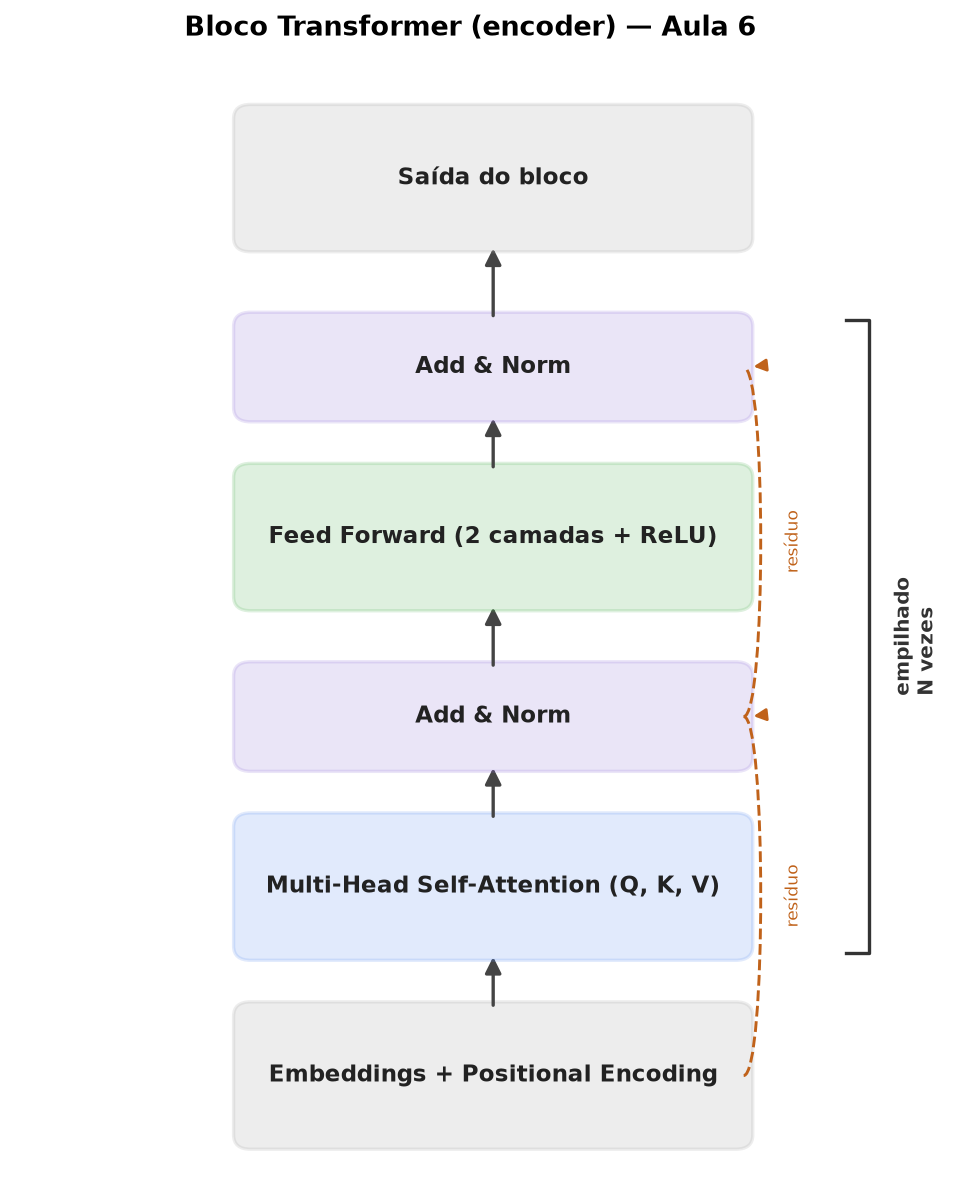

In [14]:
# STACKING 2 TRANSFORMER BLOCS – EXEMPLO COMPLETO

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
torch.manual_seed(42)

# Tokens e vetores (embedding + posição)
tokens = ["o", "cachorro", "latiu", "alto"]
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4040295, 2.2627833, -2.0864203]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.41430452, 0.12562564, 0.83773607]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0352697, -0.01277053, 1.5968297]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.21339168, -0.95826584, -0.1597742])
}

x = torch.stack([summed[token] for token in tokens]).unsqueeze(0)  # [1, 4, 3]

# Projeção inicial para 4 dimensões (para multi-head com 2 cabeças)
proj = nn.Linear(3, 4)
x_proj = proj(x)

# Definir um bloco Transformer Encoder simplificado
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=4, num_heads=2, ffn_hidden=16):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ffn_hidden),
            nn.ReLU(),
            nn.Linear(ffn_hidden, embed_dim)
        )
        self.ln2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = self.ln1(x + attn_output)  # Residual + Norm após atenção
        ffn_output = self.ffn(x)
        x = self.ln2(x + ffn_output)  # Residual + Norm após FFN
        return x

# Empilhar 2 blocos Transformer
transformer_block1 = TransformerBlock()
transformer_block2 = TransformerBlock()

# Aplicar camada 1
x1 = transformer_block1(x_proj)

# Aplicar camada 2
x2 = transformer_block2(x1)

# Mostrar saída final de cada token após 2 blocos
print("Saída final dos tokens após 2 blocos Transformer:\n")
for i, token in enumerate(tokens):
    print(f"{token.upper()} → {x2[0, i].detach().numpy().round(3)}")


Saída final dos tokens após 2 blocos Transformer:

O → [ 1.484 -1.155 -0.617  0.289]
CACHORRO → [ 0.831  1.119 -0.697 -1.254]
LATIU → [-0.101  1.403  0.116 -1.417]
ALTO → [ 1.348  0.32  -0.247 -1.421]


Agora vamos empilhar 12 blocos (a mesma profundidade do BERT-base) e visualizar como o vetor de cada token evolui camada a camada, junto com uma projeção PCA das representações finais.

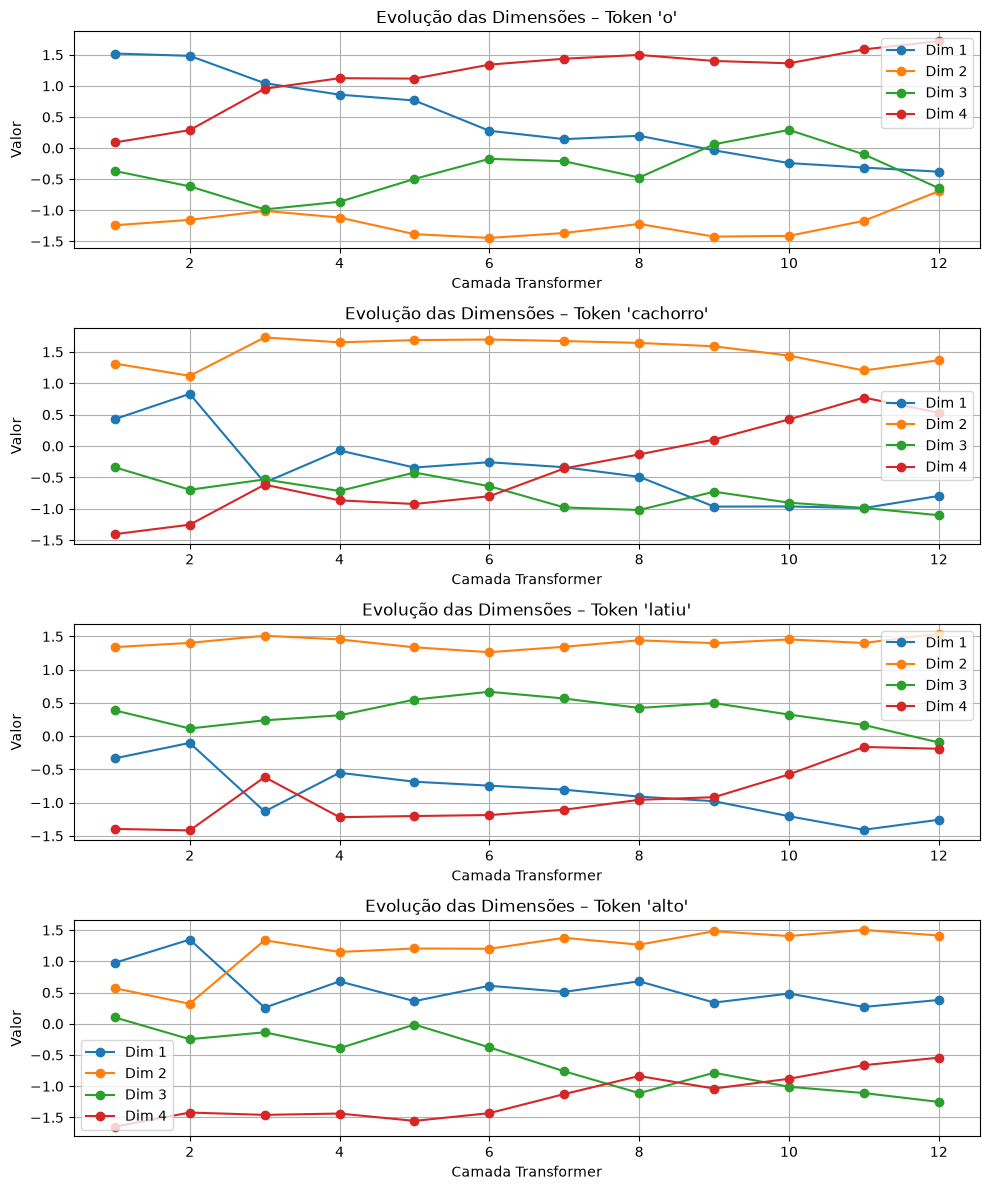

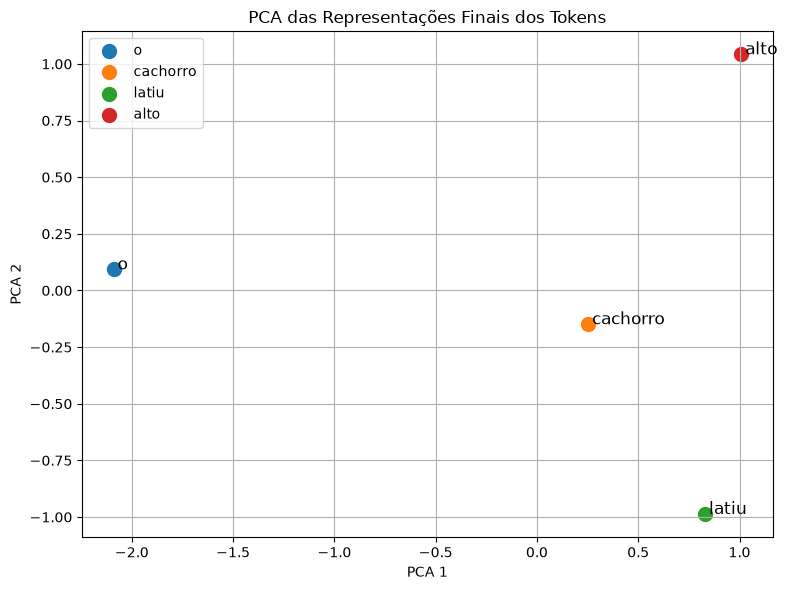

In [15]:
# VISUALIZAÇÃO COMPLETA: EVOLUÇÃO DAS 4 DIMENSÕES + PCA

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
torch.manual_seed(42)

# Tokens e vetores (embedding + posição)
tokens = ["o", "cachorro", "latiu", "alto"]
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4040295, 2.2627833, -2.0864203]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.41430452, 0.12562564, 0.83773607]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0352697, -0.01277053, 1.5968297]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.21339168, -0.95826584, -0.1597742])
}

x = torch.stack([summed[token] for token in tokens]).unsqueeze(0)  # [1, 4, 3]

# Projeção inicial para 4 dimensões
proj = nn.Linear(3, 4)
x_proj = proj(x)

# Bloco Transformer
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=4, num_heads=2, ffn_hidden=16):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ffn_hidden),
            nn.ReLU(),
            nn.Linear(ffn_hidden, embed_dim)
        )
        self.ln2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = self.ln1(x + attn_output)
        ffn_output = self.ffn(x)
        x = self.ln2(x + ffn_output)
        return x

# Empilhar 12 blocos Transformer
layers = [TransformerBlock() for _ in range(12)]

# Rastrear evolução de todos os tokens
token_evolution = {t: [] for t in tokens}
current = x_proj

for layer in layers:
    current = layer(current)
    for i, t in enumerate(tokens):
        token_evolution[t].append(current[0, i].detach().numpy())

# ==== PARTE 1: SUBPLOTS DAS 4 DIMENSÕES PARA CADA TOKEN ====
fig, axs = plt.subplots(4, 1, figsize=(10, 12))
for i, t in enumerate(tokens):
    vecs = np.array(token_evolution[t])  # [12, 4]
    for dim in range(4):
        axs[i].plot(range(1, 13), vecs[:, dim], marker='o', label=f'Dim {dim+1}')
    axs[i].set_title(f"Evolução das Dimensões – Token '{t}'")
    axs[i].set_xlabel("Camada Transformer")
    axs[i].set_ylabel("Valor")
    axs[i].legend()
    axs[i].grid(True)
plt.tight_layout()
plt.show()

# ==== PARTE 2: PCA DAS REPRESENTAÇÕES FINAIS ====
# Pegar vetores da última camada (camada 12)
final_vectors = np.array([token_evolution[t][-1] for t in tokens])  # [4, 4]

# Aplicar PCA para reduzir de 4D para 2D
pca = PCA(n_components=2)
proj_2d = pca.fit_transform(final_vectors)

# Plotar projeção
plt.figure(figsize=(8, 6))
for i, t in enumerate(tokens):
    plt.scatter(proj_2d[i, 0], proj_2d[i, 1], label=t, s=100)
    plt.text(proj_2d[i, 0] + 0.02, proj_2d[i, 1], t, fontsize=12)

plt.title("PCA das Representações Finais dos Tokens")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 7. Gerando texto com um mini-Transformer

O modelo que construímos até aqui é um **encoder puro** (como o BERT): ele processa a frase inteira de uma vez e não foi treinado para prever a próxima palavra. Mas podemos simular uma predição: passar candidatos a próxima palavra pelo mesmo encoder, e escolher o candidato cujo vetor final é mais **similar** (por cosseno) ao vetor do último token da frase.

In [16]:
# PREVISÃO SIMULADA DA PRÓXIMA PALAVRA – USANDO SEMELHANÇA VETORIAL

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
torch.manual_seed(42)

# Tokens principais e vetores (embedding + posição)
tokens = ["o", "cachorro", "latiu"]
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4040295, 2.2627833, -2.0864203]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.41430452, 0.12562564, 0.83773607]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0352697, -0.01277053, 1.5968297]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.21339168, -0.95826584, -0.1597742]),
    "rápido": torch.tensor([0.8, -0.3, 0.6]) + torch.tensor([-0.5, 0.1, 0.2]),
    "triste": torch.tensor([-0.2, -0.7, -0.3]) + torch.tensor([0.3, 0.05, 0.4]),
    "devagar": torch.tensor([0.4, -0.1, 0.3]) + torch.tensor([0.1, 0.2, -0.2])
}

# Construir frase de entrada ("o cachorro latiu")
entrada_tokens = ["o", "cachorro", "latiu"]
x = torch.stack([summed[token] for token in entrada_tokens]).unsqueeze(0)  # [1, 3, 3]

# Projeção e bloco Transformer (como antes)
proj = nn.Linear(3, 4)
x_proj = proj(x)

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=4, num_heads=2, ffn_hidden=16):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ffn_hidden),
            nn.ReLU(),
            nn.Linear(ffn_hidden, embed_dim)
        )
        self.ln2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = self.ln1(x + attn_output)
        ffn_output = self.ffn(x)
        x = self.ln2(x + ffn_output)
        return x

# Empilhar 12 camadas Transformer
layers = [TransformerBlock() for _ in range(12)]
current = x_proj
for layer in layers:
    current = layer(current)

# Vetor contextualizado do último token da entrada ("latiu")
vetor_latiu = current[0, -1].detach().numpy().reshape(1, -1)

# Vetores dos candidatos
candidatos = ["alto", "rápido", "triste", "devagar"]
candidato_vetores = []

for token in candidatos:
    vec = proj(summed[token].unsqueeze(0)).unsqueeze(0)  # [1,1,4]
    for layer in layers:
        vec = layer(vec)
    candidato_vetores.append(vec[0, 0].detach().numpy())

# Calcular similaridade com "latiu"
sims = cosine_similarity(vetor_latiu, candidato_vetores)[0]

# Mostrar resultados
print("\nPrevisão Simulada da Próxima Palavra após 'o cachorro latiu':")
for token, score in sorted(zip(candidatos, sims), key=lambda x: -x[1]):
    print(f"{token:<10} → Similaridade: {score:.4f}")



Previsão Simulada da Próxima Palavra após 'o cachorro latiu':
devagar    → Similaridade: 0.7251
triste     → Similaridade: 0.7096
alto       → Similaridade: 0.6182
rápido     → Similaridade: 0.4459


O mesmo princípio, repetido palavra por palavra, permite gerar uma frase inteira a partir de um prefixo -- vamos encapsular isso numa classe reutilizável.

In [17]:
# CLASSE REUTILIZÁVEL DO MINI-TRANSFORMER PARA GERAÇÃO DE TEXTO

import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
torch.manual_seed(42)

# Bloco Transformer reutilizável
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=4, num_heads=2, ffn_hidden=16):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ffn_hidden),
            nn.ReLU(),
            nn.Linear(ffn_hidden, embed_dim)
        )
        self.ln2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = self.ln1(x + attn_output)
        ffn_output = self.ffn(x)
        x = self.ln2(x + ffn_output)
        return x

# Modelo completo de geração
class MiniTransformerTextGenerator:
    def __init__(self, embeddings, candidatos, embed_dim=4, n_layers=12):
        self.embeddings = embeddings
        self.candidatos = candidatos
        self.proj = nn.Linear(3, embed_dim)
        self.layers = nn.ModuleList([TransformerBlock(embed_dim, num_heads=2) for _ in range(n_layers)])

    def encode(self, tokens):
        x = torch.stack([self.embeddings[tok] for tok in tokens]).unsqueeze(0)
        x_proj = self.proj(x)
        for layer in self.layers:
            x_proj = layer(x_proj)
        return x_proj

    def gerar(self, frase_inicial, passos=5):
        frase = frase_inicial[:]
        for _ in range(passos):
            if not self.candidatos:
                break

            entrada = self.encode(frase)
            contexto = entrada[0, -1].detach().numpy().reshape(1, -1)

            disponiveis = [c for c in self.candidatos if c not in frase]
            if not disponiveis:
                break

            vetores = []
            for token in disponiveis:
                vec = self.encode([token])[0, 0].detach().numpy()
                vetores.append(vec)

            sims = cosine_similarity(contexto, vetores)[0]
            proxima = disponiveis[np.argmax(sims)]
            frase.append(proxima)

        return " ".join(frase)

# Embeddings simulados
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4, 2.2, -2.0]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.4, 0.1, 0.8]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0, -0.01, 1.5]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.2, -0.9, -0.1]),
    "triste": torch.tensor([-0.2, -0.7, -0.3]) + torch.tensor([0.3, 0.05, 0.4]),
    "rápido": torch.tensor([0.8, -0.3, 0.6]) + torch.tensor([-0.5, 0.1, 0.2]),
    "devagar": torch.tensor([0.4, -0.1, 0.3]) + torch.tensor([0.1, 0.2, -0.2]),
    "à": torch.tensor([-0.4, 0.6, 0.2]) + torch.tensor([0.2, 0.1, 0.3]),
    "noite": torch.tensor([0.7, 0.1, -0.2]) + torch.tensor([-0.3, 0.4, 0.1]),
    "correndo": torch.tensor([0.5, 0.2, 0.3]) + torch.tensor([0.3, -0.1, 0.2]),
    "muito": torch.tensor([0.6, -0.2, 0.1]) + torch.tensor([0.0, 0.3, 0.2])
}

candidatos = ["alto", "triste", "rápido", "devagar", "à", "noite", "correndo", "muito"]

# Criar o modelo e gerar texto
modelo = MiniTransformerTextGenerator(summed, candidatos)
frase_inicial = ["o", "cachorro", "latiu"]
resultado = modelo.gerar(frase_inicial, passos=5)
print("\nFrase gerada:")
print(resultado)


Frase gerada:
o cachorro latiu muito rápido à triste devagar


**Importante:** como o encoder ainda não foi treinado para a tarefa de geração, o texto resultante não tem garantia de fazer sentido gramatical -- ele só reflete similaridade vetorial entre embeddings aleatórios. É uma simulação didática do *mecanismo* de geração, não um modelo de linguagem funcional.

## 8. Um Transformer real, treinado de verdade

Para fechar, vamos treinar um Transformer de verdade -- com backpropagation ajustando todos os pesos (embeddings, atenção, feedforward) -- usando o módulo `nn.TransformerEncoderLayer` já pronto do PyTorch, em vez dos blocos que implementamos à mão. A tarefa é simples (prever a próxima palavra de `"o cachorro latiu alto"`), mas o mecanismo de treino é exatamente o mesmo usado para treinar modelos como o GPT, só que em escala muito menor.

In [18]:
# Treinamento didático de um Transformer com a frase "o cachorro latiu alto"
# Foco: compreensão educacional da arquitetura

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np

# ============================
# 1. Dados de exemplo
# ============================
sentence = "o cachorro latiu alto"
vocab = list(set(sentence.split()))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

# Exemplo: "o cachorro latiu alto" → entrada: ["o", "cachorro", "latiu"] → alvo: ["cachorro", "latiu", "alto"]
inputs = [[word2idx[w] for w in sentence.split()[:-1]]]
targets = [[word2idx[w] for w in sentence.split()[1:]]]

inputs = torch.tensor(inputs)
targets = torch.tensor(targets)

# ============================
# 2. Modelo Transformer mínimo
# ============================
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=16, nhead=2, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, 3, d_model))  # para 3 posições
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        emb = self.embedding(x) + self.pos_encoder[:, :x.size(1), :]
        out = self.transformer(emb)
        return self.decoder(out)

# ============================
# 3. Treinamento didático
# ============================
vocab_size = len(vocab)
model = TinyTransformer(vocab_size)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    output = model(inputs)
    loss = criterion(output.view(-1, vocab_size), targets.view(-1))
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        pred = output.argmax(dim=-1)
        decoded = [idx2word[i.item()] for i in pred[0]]
        print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Pred: {decoded}")

# ============================
# 4. Teste com nova entrada
# ============================
print("\nFrase original:", sentence)
print("Predição final:", decoded)


Epoch 0 | Loss: 1.6158 | Pred: ['o', 'alto', 'latiu']
Epoch 10 | Loss: 0.1673 | Pred: ['cachorro', 'latiu', 'alto']
Epoch 20 | Loss: 0.0378 | Pred: ['cachorro', 'latiu', 'alto']
Epoch 30 | Loss: 0.0211 | Pred: ['cachorro', 'latiu', 'alto']
Epoch 40 | Loss: 0.0070 | Pred: ['cachorro', 'latiu', 'alto']
Epoch 50 | Loss: 0.0047 | Pred: ['cachorro', 'latiu', 'alto']
Epoch 60 | Loss: 0.0024 | Pred: ['cachorro', 'latiu', 'alto']
Epoch 70 | Loss: 0.0022 | Pred: ['cachorro', 'latiu', 'alto']
Epoch 80 | Loss: 0.0022 | Pred: ['cachorro', 'latiu', 'alto']
Epoch 90 | Loss: 0.0021 | Pred: ['cachorro', 'latiu', 'alto']



Frase original: o cachorro latiu alto
Predição final: ['cachorro', 'latiu', 'alto']


O loss caindo e a predição convergindo para a sequência correta mostram o Transformer aprendendo via backpropagation -- a mesma regra de ajuste de pesos que vimos pela primeira vez no perceptron da Aula 1, agora treinando uma arquitetura com atenção, múltiplas camadas e milhares de parâmetros.

## Fechamento: o percurso completo

Ao longo de seis aulas, percorremos o caminho de um único neurônio até um Transformer:

1. **Aula 1**: um neurônio, pesos manuais, a regra de erro do perceptron.
2. **Aula 2**: vários neurônios em camadas, quebra de simetria, ReLU e sigmoid.
3. **Aula 3**: a mesma rede, agora treinada de verdade com Keras e PyTorch via backpropagation.
4. **Aula 4**: arquiteturas especializadas -- CNN, RNN, LSTM, GAN, Autoencoder -- cada uma motivada pela limitação da anterior.
5. **Aula 5**: RNN/LSTM/GRU aplicadas a texto, e a evolução dos embeddings estáticos aos contextuais.
6. **Aula 6**: o mecanismo de atenção por trás dos embeddings contextuais, e o Transformer completo.

**Para refletir:** todas essas arquiteturas -- do perceptron ao Transformer -- são treinadas com a mesma ideia central: comparar uma previsão com o valor esperado, calcular um erro, e ajustar os pesos para reduzi-lo. O que mudou, de aula para aula, não foi o princípio de aprendizado, e sim a forma como a informação flui pela rede antes desse ajuste. Que tipo de estrutura de dados (imagem, texto, série temporal, grafo) você imagina que ainda não foi coberta por nenhuma das arquiteturas desta disciplina -- e que tipo de arquitetura ela exigiria?

# **Referências**

BA, J. L.; KIROS, J. R.; HINTON, G. E. Layer normalization. **arXiv preprint** arXiv:1607.06450, 2016.

BROWN, T. et al. Language models are few-shot learners. In: ADVANCES IN NEURAL INFORMATION PROCESSING SYSTEMS (NeurIPS), 33., 2020. **Anais [...]**. p. 1877-1901, 2020.

DEVLIN, J. et al. BERT: pre-training of deep bidirectional transformers for language understanding. In: CONFERENCE OF THE NORTH AMERICAN CHAPTER OF THE ASSOCIATION FOR COMPUTATIONAL LINGUISTICS (NAACL), 2019. **Anais [...]**. p. 4171-4186, 2019.

HE, K. et al. Deep residual learning for image recognition. In: IEEE CONFERENCE ON COMPUTER VISION AND PATTERN RECOGNITION (CVPR), 2016. **Anais [...]**. p. 770-778, 2016.

RADFORD, A. et al. Language models are unsupervised multitask learners. **OpenAI**, 2019.

VASWANI, A. et al. Attention is all you need. In: ADVANCES IN NEURAL INFORMATION PROCESSING SYSTEMS (NeurIPS), 30., 2017. **Anais [...]**. p. 5998-6008, 2017.